# ***ANALYZING THE PIZZA PLACE SALES***



In [1]:
##importing necessary libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
##reading csv files/dataset

orders=pd.read_csv(r'/content/orders.csv')
order_details=pd.read_csv(r'/content/order_details.csv')
pizzas=pd.read_csv(r'/content/pizzas.csv')
pizza_types=pd.read_csv(r'/content/pizza_types.csv', encoding='latin1')
data_dictionary=pd.read_csv(r'/content/data_dictionary.csv')
data_dictionary

,Table,Field,Description
0,orders,order_id,Unique identifier for each order placed by a t...
1,orders,date,Date the order was placed (entered into the sy...
2,orders,time,Time the order was placed (entered into the sy...
3,order_details,order_details_id,Unique identifier for each pizza placed within...
4,order_details,order_id,Foreign key that ties the details in each orde...
5,order_details,pizza_id,Foreign key that ties the pizza ordered to its...
6,order_details,quantity,Quantity ordered for each pizza of the same ty...
7,pizzas,pizza_id,Unique identifier for each pizza (constituted ...
8,pizzas,pizza_type_id,Foreign key that ties each pizza to its broade...
9,pizzas,size,"Size of the pizza (Small, Medium, Large, X Lar..."


In [3]:
orders.info()
orders.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21350 entries, 0 to 21349
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   order_id  21350 non-null  int64 
 1   date      21350 non-null  object
 2   time      21350 non-null  object
dtypes: int64(1), object(2)
memory usage: 500.5+ KB


(21350, 3)

In [4]:
order_details.info()
order_details.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   order_details_id  48620 non-null  int64 
 1   order_id          48620 non-null  int64 
 2   pizza_id          48620 non-null  object
 3   quantity          48620 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


(48620, 4)

In [5]:
pizzas.info()
pizzas.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pizza_id       96 non-null     object 
 1   pizza_type_id  96 non-null     object 
 2   size           96 non-null     object 
 3   price          96 non-null     float64
dtypes: float64(1), object(3)
memory usage: 3.1+ KB


(96, 4)

In [6]:
pizza_types.info()
pizza_types.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   pizza_type_id  32 non-null     object
 1   name           32 non-null     object
 2   category       32 non-null     object
 3   ingredients    32 non-null     object
dtypes: object(4)
memory usage: 1.1+ KB


(32, 4)

# **DATA MERGING**

Merging (outer) the first two dataset by a unique identifier





In [7]:
dataset_1=pd.merge(orders,order_details, on='order_id', how='outer')
dataset_1

,order_id,date,time,order_details_id,pizza_id,quantity
0,1,2015-01-01,11:38:36,1,hawaiian_m,1
1,2,2015-01-01,11:57:40,2,classic_dlx_m,1
2,2,2015-01-01,11:57:40,3,five_cheese_l,1
3,2,2015-01-01,11:57:40,4,ital_supr_l,1
4,2,2015-01-01,11:57:40,5,mexicana_m,1
...,...,...,...,...,...,...
48615,21348,2015-12-31,21:23:10,48616,ckn_alfredo_m,1
48616,21348,2015-12-31,21:23:10,48617,four_cheese_l,1
48617,21348,2015-12-31,21:23:10,48618,napolitana_s,1
48618,21349,2015-12-31,22:09:54,48619,mexicana_l,1


Merging (outer) the last two dataset by a unique

In [8]:
dataset_2=pd.merge(pizzas,pizza_types, on='pizza_type_id', how='outer')
dataset_2

,pizza_id,pizza_type_id,size,price,name,category,ingredients
0,bbq_ckn_s,bbq_ckn,S,12.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,bbq_ckn_m,bbq_ckn,M,16.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
2,bbq_ckn_l,bbq_ckn,L,20.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
3,big_meat_s,big_meat,S,12.00,The Big Meat Pizza,Classic,"Bacon, Pepperoni, Italian Sausage, Chorizo Sau..."
4,big_meat_m,big_meat,M,16.00,The Big Meat Pizza,Classic,"Bacon, Pepperoni, Italian Sausage, Chorizo Sau..."
...,...,...,...,...,...,...,...
91,the_greek_xl,the_greek,XL,25.50,The Greek Pizza,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic..."
92,the_greek_xxl,the_greek,XXL,35.95,The Greek Pizza,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic..."
93,veggie_veg_s,veggie_veg,S,12.00,The Vegetables + Vegetables Pizza,Veggie,"Mushrooms, Tomatoes, Red Peppers, Green Pepper..."
94,veggie_veg_m,veggie_veg,M,16.00,The Vegetables + Vegetables Pizza,Veggie,"Mushrooms, Tomatoes, Red Peppers, Green Pepper..."


MERGING THE FOUR DATASEET TO A DATAFRAME

In [9]:
dataset_combined=pd.merge(dataset_1,dataset_2, on='pizza_id', how='outer')
dataset_combined

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients
0,11.0,2015-01-01,13:02:59,26.0,bbq_ckn_l,1.0,bbq_ckn,L,20.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,17.0,2015-01-01,13:53:00,43.0,bbq_ckn_l,1.0,bbq_ckn,L,20.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
2,27.0,2015-01-01,15:11:17,71.0,bbq_ckn_l,1.0,bbq_ckn,L,20.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
3,33.0,2015-01-01,15:54:08,83.0,bbq_ckn_l,1.0,bbq_ckn,L,20.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
4,51.0,2015-01-01,18:48:28,123.0,bbq_ckn_l,1.0,bbq_ckn,L,20.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
...,...,...,...,...,...,...,...,...,...,...,...,...
48620,21251.0,2015-12-30,12:45:20,48406.0,veggie_veg_s,2.0,veggie_veg,S,12.00,The Vegetables + Vegetables Pizza,Veggie,"Mushrooms, Tomatoes, Red Peppers, Green Pepper..."
48621,21296.0,2015-12-31,15:13:40,48493.0,veggie_veg_s,1.0,veggie_veg,S,12.00,The Vegetables + Vegetables Pizza,Veggie,"Mushrooms, Tomatoes, Red Peppers, Green Pepper..."
48622,21298.0,2015-12-31,15:35:37,48500.0,veggie_veg_s,1.0,veggie_veg,S,12.00,The Vegetables + Vegetables Pizza,Veggie,"Mushrooms, Tomatoes, Red Peppers, Green Pepper..."
48623,21299.0,2015-12-31,15:52:16,48503.0,veggie_veg_s,1.0,veggie_veg,S,12.00,The Vegetables + Vegetables Pizza,Veggie,"Mushrooms, Tomatoes, Red Peppers, Green Pepper..."


# **DATA CLEANING**


In [10]:
dataset_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48625 entries, 0 to 48624
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          48620 non-null  float64
 1   date              48620 non-null  object 
 2   time              48620 non-null  object 
 3   order_details_id  48620 non-null  float64
 4   pizza_id          48625 non-null  object 
 5   quantity          48620 non-null  float64
 6   pizza_type_id     48625 non-null  object 
 7   size              48625 non-null  object 
 8   price             48625 non-null  float64
 9   name              48625 non-null  object 
 10  category          48625 non-null  object 
 11  ingredients       48625 non-null  object 
dtypes: float64(4), object(8)
memory usage: 4.5+ MB


In [11]:
dataset_combined.head()

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients
0,11.0,2015-01-01,13:02:59,26.0,bbq_ckn_l,1.0,bbq_ckn,L,20.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,17.0,2015-01-01,13:53:00,43.0,bbq_ckn_l,1.0,bbq_ckn,L,20.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
2,27.0,2015-01-01,15:11:17,71.0,bbq_ckn_l,1.0,bbq_ckn,L,20.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
3,33.0,2015-01-01,15:54:08,83.0,bbq_ckn_l,1.0,bbq_ckn,L,20.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
4,51.0,2015-01-01,18:48:28,123.0,bbq_ckn_l,1.0,bbq_ckn,L,20.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."


In [12]:
dataset_combined.isna().sum()

,0
order_id,5
date,5
time,5
order_details_id,5
pizza_id,0
quantity,5
pizza_type_id,0
size,0
price,0
name,0


In [13]:
dataset_combined.fillna(0, inplace=True)
dataset_combined.isna().sum()

,0
order_id,0
date,0
time,0
order_details_id,0
pizza_id,0
quantity,0
pizza_type_id,0
size,0
price,0
name,0


In [14]:


dataset_combined['date']=pd.to_datetime(dataset_combined['date'], errors='coerce')
dataset_combined['time']=pd.to_datetime(dataset_combined['time'], errors='coerce')

/tmp/ipython-input-1167801237.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset_combined['time']=pd.to_datetime(dataset_combined['time'], errors='coerce')


In [15]:
dataset_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48625 entries, 0 to 48624
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          48625 non-null  float64       
 1   date              48620 non-null  datetime64[ns]
 2   time              48625 non-null  datetime64[ns]
 3   order_details_id  48625 non-null  float64       
 4   pizza_id          48625 non-null  object        
 5   quantity          48625 non-null  float64       
 6   pizza_type_id     48625 non-null  object        
 7   size              48625 non-null  object        
 8   price             48625 non-null  float64       
 9   name              48625 non-null  object        
 10  category          48625 non-null  object        
 11  ingredients       48625 non-null  object        
dtypes: datetime64[ns](2), float64(4), object(6)
memory usage: 4.5+ MB


In [16]:
dataset_combined.sample(10)

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients
5425,18623.0,2015-11-13,2025-09-27 22:29:20,42327.0,calabrese_m,1.0,calabrese,M,16.25,The Calabrese Pizza,Supreme,"Nduja Salami, Pancetta, Tomatoes, Red Onions,..."
18260,9282.0,2015-06-05,2025-09-27 14:36:07,21164.0,hawaiian_s,1.0,hawaiian,S,10.50,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
24770,19690.0,2015-12-01,2025-09-27 13:24:16,44805.0,mexicana_l,1.0,mexicana,L,20.25,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."
19098,8852.0,2015-05-29,2025-09-27 12:39:40,20119.0,ital_cpcllo_l,1.0,ital_cpcllo,L,20.50,The Italian Capocollo Pizza,Classic,"Capocollo, Red Peppers, Tomatoes, Goat Cheese,..."
28701,14073.0,2015-08-23,2025-09-27 11:38:00,31885.0,pepperoni_l,1.0,pepperoni,L,15.25,The Pepperoni Pizza,Classic,"Mozzarella Cheese, Pepperoni"
20669,13327.0,2015-08-10,2025-09-27 20:00:28,30166.0,ital_supr_l,1.0,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
13128,13284.0,2015-08-10,2025-09-27 11:52:49,30070.0,five_cheese_l,1.0,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
16645,4759.0,2015-03-21,2025-09-27 17:08:35,10867.0,hawaiian_l,1.0,hawaiian,L,16.50,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
6305,17346.0,2015-10-22,2025-09-27 13:21:29,39390.0,cali_ckn_l,1.0,cali_ckn,L,20.75,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
14649,17480.0,2015-10-24,2025-09-27 17:19:27,39701.0,four_cheese_l,1.0,four_cheese,L,17.95,The Four Cheese Pizza,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo..."


# **EXPLORATORY DATA ANALYSIS**

In [17]:
## total revenue sale
dataset_combined['revenue']=dataset_combined['quantity']*dataset_combined['price']
total_sales=dataset_combined['revenue'].sum()
print(f'the total revenue is {total_sales}')

the total revenue is 817860.0499999999


In [18]:
##total quantity sold
total_quantity=dataset_combined['quantity'].sum()
print (f'the total quantity sold is {total_quantity}')

the total quantity sold is 49574.0


In [19]:
##total orders
total_orders=dataset_combined['order_id'].nunique()
print (f' the total order is {total_orders}')

 the total order is 21351


In [20]:
##how many pizza types was sold
pizza_types_sold=dataset_combined['pizza_type_id'].value_counts()
print(f'The pizza place sell {pizza_types_sold.nunique()} different types of pizza')

The pizza place sell 30 different types of pizza


In [21]:
## average price of the pizzas
average_price=dataset_combined['price'].mean()
print(f' the average price of pizza is {average_price}')

 the average price of pizza is 16.494004113110538


In [30]:
##the peak hour of sales
peak_hour=dataset_combined['time'].dt.hour.value_counts()
print(f' the peak hour of sales is at {peak_hour.idxmax()} with {peak_hour.max()} sales')


 the peak hour of sales is at 12 with 6543 sales


In [23]:
##total sales made on each day of the week
dataset_combined.sample(10)
dataset_combined['day_of_week']=dataset_combined['date'].dt.day_name()
total_sales_for_the_day=dataset_combined.groupby('day_of_week')['revenue'].sum()
total_sales_for_the_day
print(f'The day with the highest number of sales is {total_sales_for_the_day.idxmax()} with number of sale of {total_sales_for_the_day.max()}')

The day with the highest number of sales is Friday with number of sale of 136073.9


In [24]:
##the top 5 bestselling pizzas
dataset_combined.sample(10)
top_5_bestselling_pizzas=dataset_combined.groupby('name')['quantity'].sum().sort_values(ascending=False).head(5).reset_index()
top_5_bestselling_pizzas

,name,quantity
0,The Classic Deluxe Pizza,2453.0
1,The Barbecue Chicken Pizza,2432.0
2,The Hawaiian Pizza,2422.0
3,The Pepperoni Pizza,2418.0
4,The Thai Chicken Pizza,2371.0


In [44]:
##sales made in each month
dataset_combined['month']=dataset_combined['date'].dt.month_name()
sales_made_in_each_month=dataset_combined.groupby('month')['revenue'].sum().sort_values(ascending=False)
sales_made_in_each_month

,revenue
month,
July,72557.90
May,71402.75
March,70397.10
November,70395.35
January,69793.30
April,68736.80
August,68278.25
June,68230.20
February,65159.60


from the chart shown below, we can see that there is a spike on the sales in the month of july, therefore, july has the highest sales

<function matplotlib.pyplot.show(close=None, block=None)>

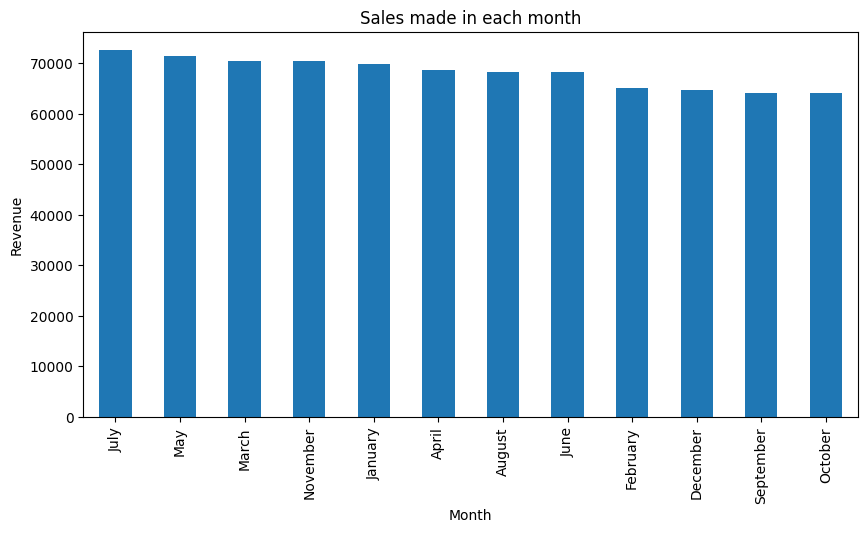

In [48]:
sales_made_in_each_month.plot( title='Sales made in each month', xlabel='Month', ylabel='Revenue', kind='bar', figsize=(10,5))
plt.show

In [27]:
##pizza types that are performining low
low_performance_pizza_types=dataset_combined.groupby('name')['revenue'].sum()
low_performance_pizza_types.sort_values(ascending=False).tail(5)

,revenue
name,
The Spinach Pesto Pizza,15596.00
The Mediterranean Pizza,15360.50
The Spinach Supreme Pizza,15277.75
The Green Garden Pizza,13955.75
The Brie Carre Pizza,11588.50
